# 🦾 Inverse Kinematics Planar Robot 3-DOF
## Pendekatan Machine Learning, Deep Learning
---
> **Prasyarat:** Python, NumPy, dasar ML & Neural Network  
> **Tools:** `numpy`, `matplotlib`, `scikit-learn`, `torch`, `gymnasium`, `stable-baselines3`


---
## 📖 Bagian 1: Pengantar Forward & Inverse Kinematics

### Apa itu Kinematika Robot?

**Forward Kinematics (FK):** Diberikan sudut sendi → hitung posisi end-effector  
- Mudah ✅, solusi **unik**

**Inverse Kinematics (IK):** Diberikan posisi target → hitung sudut sendi  
- Sulit ⚠️, solusi bisa **banyak** atau **tidak ada**

### Robot Planar 3-DOF
- 3 link (lengan): `L1=0.5m`, `L2=0.4m`, `L3=0.3m`
- 3 sendi (joint): `θ1, θ2, θ3` (dalam radian)
- End-effector: ujung lengan ke-3

### Persamaan FK:
```
x = L1·cos(θ1) + L2·cos(θ1+θ2) + L3·cos(θ1+θ2+θ3)
y = L1·sin(θ1) + L2·sin(θ1+θ2) + L3·sin(θ1+θ2+θ3)
```

### 3 Pendekatan IK dengan AI:
| Pendekatan | Metode | Kelebihan |
|------------|--------|-----------|
| **ML** | Supervised (KNN, RF, SVR) | Cepat, mudah dipahami |
| **DL** | Neural Network (PyTorch) | Akurat, generalisasi baik |



In [20]:
# Install dependencies (jalankan sekali)
!pip install gymnasium stable-baselines3 scikit-learn torch matplotlib numpy tqdm
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.patches import Circle
from IPython.display import HTML
import warnings
warnings.filterwarnings('ignore')

print("✅ Library siap!")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 25.3 MB/s eta 0:00:00
  Attempting uninstall: gymnasium
    Found existing installation: gymnasium 1.3.0
    Uninstalling gymnasium-1.3.0:
      Successfully uninstalled gymnasium-1.3.0
✅ Library siap!


In [24]:
# ─── Konfigurasi Robot Baru ───────────────────────────────────────────
L1, L2, L3 = 0.5, 0.4, 0.3      # Panjang link baru (meter)
LINK_LENGTHS = np.array([L1, L2, L3])
JOINT_LIMIT  = np.pi              # ±π radian per sendi
MAX_REACH    = L1 + L2 + L3       # Otomatis menjadi 1.2 m

min_reach = max(0.0, L1 - L2 - L3) # Untuk 0.5, 0.4, 0.3 -> min_reach = 0

def forward_kinematics(theta):
    """Hitung posisi setiap sendi dari sudut theta = [θ1, θ2, θ3]."""
    t1, t2, t3 = theta
    p0 = np.array([0.0, 0.0])
    p1 = p0 + L1 * np.array([np.cos(t1), np.sin(t1)])
    p2 = p1 + L2 * np.array([np.cos(t1+t2), np.sin(t1+t2)])
    p3 = p2 + L3 * np.array([np.cos(t1+t2+t3), np.sin(t1+t2+t3)])
    return p0, p1, p2, p3

def get_end_effector(theta):
    """Langsung return posisi end-effector (p3)."""
    return forward_kinematics(theta)[3]

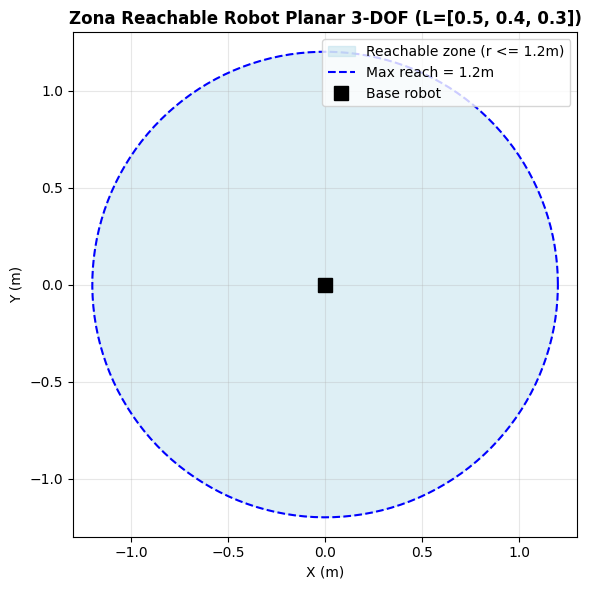

Demo Reachability Check Baru:
   Target               | Jarak    | Reachable?
   ---------------------------------------------
   (0.5, 0.3)             | 0.5831 m | YES
   (0.8, 0.6)             | 1.0000 m | YES
   (1.1, 0.0)             | 1.1000 m | YES
   (1.3, 0.0)             | 1.3000 m | NO
   (0.0, 0.0)             | 0.0000 m | YES




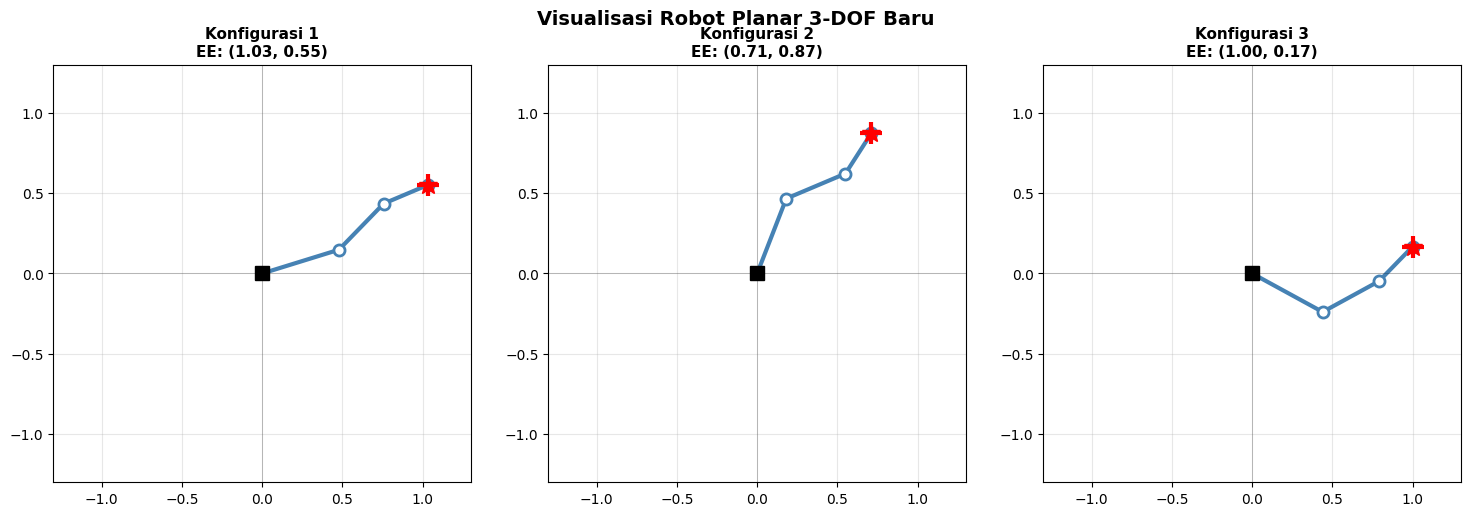

✅ Robot berhasil divisualisasi dengan dimensi baru!


In [26]:
# ─── Fungsi Reachability Check ───────────────────────────────────────
def is_reachable(target, tol=1e-6):
    """Cek apakah posisi target dapat dijangkau robot planar 3-DOF dengan dimensi baru."""
    target = np.array(target, dtype=float)
    dist = np.linalg.norm(target)
    # Target reachable jika berada di antara jangkauan minimum dan maksimum
    return bool(min_reach - tol <= dist <= MAX_REACH + tol)

def filter_reachable(positions, labels=None):
    """Filter array posisi, kembalikan hanya yang reachable."""
    mask = np.array([is_reachable(p) for p in positions])
    if labels is not None:
        return positions[mask], labels[mask], mask
    return positions[mask], mask

# ─── Fungsi Plot Robot ────────────────────────────────────────────────
def plot_robot(ax, theta, target=None, title="Robot", color='steelblue'):
    p0, p1, p2, p3 = forward_kinematics(theta)
    points = np.array([p0, p1, p2, p3])
    ax.plot(points[:,0], points[:,1], '-o', color=color,
            linewidth=3, markersize=8, markerfacecolor='white',
            markeredgecolor=color, markeredgewidth=2)
    ax.plot(*p0, 'ks', markersize=10)   # base
    ax.plot(*p3, '*', color='red', markersize=14, label='End-effector')
    if target is not None:
        ax.plot(*target, 'r+', markersize=16, markeredgewidth=3, label='Target')
        ax.add_patch(Circle(target, 0.02, color='red', alpha=0.3))

    # Batas grafik diperbesar menjadi -1.3 s/d 1.3 karena MAX_REACH = 1.2m
    ax.set_xlim(-1.3, 1.3); ax.set_ylim(-1.3, 1.3)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.axhline(0, color='k', lw=0.5, alpha=0.3)
    ax.axvline(0, color='k', lw=0.5, alpha=0.3)

# ─── 1. Visualisasi Zona Reachable ───────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6))
theta_range = np.linspace(0, 2*np.pi, 300)
ax.fill(MAX_REACH * np.cos(theta_range),
        MAX_REACH * np.sin(theta_range),
        color='lightblue', alpha=0.4, label=f'Reachable zone (r <= {MAX_REACH:.1f}m)')
ax.plot(MAX_REACH * np.cos(theta_range),
        MAX_REACH * np.sin(theta_range),
        'b--', linewidth=1.5, label=f'Max reach = {MAX_REACH:.1f}m')
ax.plot(0, 0, 'ks', markersize=10, label='Base robot')

ax.set_xlim(-1.3, 1.3); ax.set_ylim(-1.3, 1.3)
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
ax.set_title("Zona Reachable Robot Planar 3-DOF (L=[0.5, 0.4, 0.3])", fontsize=12, fontweight='bold')
ax.set_xlabel("X (m)"); ax.set_ylabel("Y (m)")
ax.legend(loc='upper right')
plt.tight_layout(); plt.show()

# ─── 2. Demo Cek Reachability (Dengan Titik Uji yang Disesuaikan) ─────
test_points = [(0.5, 0.3), (0.8, 0.6), (1.1, 0.0), (1.3, 0.0), (0.0, 0.0)]
print("Demo Reachability Check Baru:")
print(f"   {'Target':20s} | {'Jarak':8s} | {'Reachable?':10s}")
print("   " + "-"*45)
for pt in test_points:
    d = np.linalg.norm(pt)
    r = is_reachable(pt)
    status = "YES" if r else "NO"
    print(f"   ({pt[0]:.1f}, {pt[1]:.1f}){'':12} | {d:.4f} m | {status}")

print("\n" + "="*50 + "\n")

# ─── 3. Demo Visualisasi Robot ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
configs = [
    ([0.3, 0.5, -0.4], "Konfigurasi 1"),
    ([1.2, -0.8, 0.6], "Konfigurasi 2"),
    ([-0.5, 1.0, 0.3], "Konfigurasi 3"),
]
for ax, (theta, title) in zip(axes, configs):
    ee = get_end_effector(theta)
    plot_robot(ax, theta, target=ee, title=f"{title}\nEE: ({ee[0]:.2f}, {ee[1]:.2f})")

plt.suptitle("Visualisasi Robot Planar 3-DOF Baru", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Robot berhasil divisualisasi dengan dimensi baru!")

---
## 📊 Bagian: Membuat Dataset (Sampling FK)

✅ Dataset dibuat: 18000 sampel
   Reachable  : 18000 (100.0%)
   Unreachable: 0 (0.0%)
   ✅ Semua sampel reachable (expected, karena dari FK sampling)
   Input  (theta): shape=(18000, 3)     → [θ1, θ2, θ3]
   Output (EE pos): shape=(18000, 2) → [x, y]


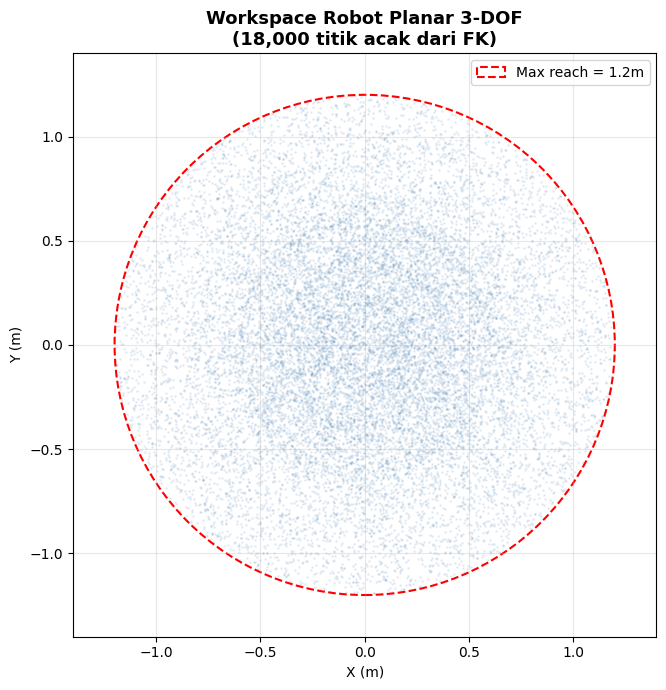

✅ Workspace dengan dimensi baru berhasil tervisualisasi!


In [27]:
# ─── Generate Dataset ────────────────────────────────────────────────
np.random.seed(42)
N = 18000  # jumlah sampel

# Random sudut sendi
thetas = np.random.uniform(-JOINT_LIMIT, JOINT_LIMIT, size=(N, 3)).astype(np.float32)

# Hitung posisi end-effector via FK
ee_positions = np.array([get_end_effector(t) for t in thetas], dtype=np.float32)

# ─── Validasi Reachability Dataset ──────────────────────────────────
_, reach_mask = filter_reachable(ee_positions)
n_reachable = int(reach_mask.sum())
n_unreachable = N - n_reachable

print(f"✅ Dataset dibuat: {N} sampel")
print(f"   Reachable  : {n_reachable} ({n_reachable/N*100:.1f}%)")
print(f"   Unreachable: {n_unreachable} ({n_unreachable/N*100:.1f}%)")

if n_unreachable > 0:
    print(f"   ⚠️  {n_unreachable} sampel dibuang (tidak reachable)")
    ee_positions = ee_positions[reach_mask]
    thetas       = thetas[reach_mask]
    print(f"   ✅ Dataset bersih: {len(ee_positions)} sampel")
else:
    print("   ✅ Semua sampel reachable (expected, karena dari FK sampling)")

print(f"   Input  (theta): shape={thetas.shape}     → [θ1, θ2, θ3]")
print(f"   Output (EE pos): shape={ee_positions.shape} → [x, y]")

# ─── Visualisasi Workspace Robot ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(ee_positions[:,0], ee_positions[:,1],
           alpha=0.1, s=1, color='steelblue')

# Mengubah judul teks agar sesuai dengan jumlah N (18.000 titik)
ax.set_title(f"Workspace Robot Planar 3-DOF\n({N:,} titik acak dari FK)", fontsize=13, fontweight='bold')
ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")

# Mengatur batas grafik secara eksplisit agar pas dengan dimensi baru (MAX_REACH = 1.2m)
ax.set_xlim(-1.4, 1.4)
ax.set_ylim(-1.4, 1.4)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

# Tambahkan lingkaran batas luar maksimal jangkauan baru
circle = plt.Circle((0,0), MAX_REACH, fill=False, color='red',
                    linestyle='--', linewidth=1.5, label=f'Max reach = {MAX_REACH:.1f}m')
ax.add_patch(circle)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()
print("✅ Workspace dengan dimensi baru berhasil tervisualisasi!")

In [28]:
# ─── Split Dataset ───────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

# X = posisi target (ee_positions), y = sudut sendi (thetas)
# Memisahkan 80% data untuk training dan 20% data untuk testing
X_train, X_test, y_train, y_test = train_test_split(
    ee_positions, thetas, test_size=0.2, random_state=42)

print(f"✅ Data berhasil dipisahkan:")
print(f"   Train (X_train, y_train): {X_train.shape[0]} sampel")
print(f"   Test  (X_test, y_test)  : {X_test.shape[0]} sampel")

✅ Data berhasil dipisahkan:
   Train (X_train, y_train): 14400 sampel
   Test  (X_test, y_test)  : 3600 sampel


---
## 🤖 Bagian: — Machine Learning (Supervised)

**Ide:** Buat model regresi dari data (x,y) → (θ1,θ2,θ3)  
Model akan belajar memetakan posisi target ke sudut sendi.


In [31]:
import time
import numpy as np
from sklearn.svm import SVR
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler

# ─── Normalisasi ─────────────────────────────────────────────────────
scaler_X = StandardScaler()
X_train_s = scaler_X.fit_transform(X_train)
X_test_s  = scaler_X.transform(X_test)

ml_results = {}

# ─── 1. Support Vector Regression (SVR) ───────────────────────────────
print("🔮 Training Support Vector Regression (SVR)...")
t0 = time.time()
# Menggunakan kernel 'rbf' untuk menangani non-linearitas invers kinematiks
svr_base = SVR(kernel='rbf', C=10.0, epsilon=0.01)
svr_model = MultiOutputRegressor(svr_base, n_jobs=-1)
svr_model.fit(X_train_s, y_train)
svr_pred = svr_model.predict(X_test_s)
t_svr = time.time() - t0

# Hitung error di end-effector (bukan di sudut)
svr_ee  = np.array([get_end_effector(p) for p in svr_pred])
svr_err = np.linalg.norm(svr_ee - X_test, axis=1)
ml_results['SVR'] = {'pred': svr_pred, 'ee_err': svr_err, 'time': t_svr}
print(f"   ✅ SVR — mean EE error: {svr_err.mean()*100:.2f} cm | time: {t_svr:.1f}s")


# ─── 2. HistGradientBoosting Regressor ────────────────────────────────
print("🚀 Training HistGradientBoosting (Gradient Boosting)...")
t0 = time.time()
hgb_base = HistGradientBoostingRegressor(max_iter=150, random_state=42)
hgb_model = MultiOutputRegressor(hgb_base, n_jobs=-1)
hgb_model.fit(X_train_s, y_train)
hgb_pred = hgb_model.predict(X_test_s)
t_hgb = time.time() - t0

hgb_ee  = np.array([get_end_effector(p) for p in hgb_pred])
hgb_err = np.linalg.norm(hgb_ee - X_test, axis=1)
ml_results['Gradient Boosting'] = {'pred': hgb_pred, 'ee_err': hgb_err, 'time': t_hgb}
print(f"   ✅ HistGB — mean EE error: {hgb_err.mean()*100:.2f} cm | time: {t_hgb:.1f}s")

🔮 Training Support Vector Regression (SVR)...
   ✅ SVR — mean EE error: 63.27 cm | time: 49.9s
🚀 Training HistGradientBoosting (Gradient Boosting)...
   ✅ HistGB — mean EE error: 80.81 cm | time: 0.4s


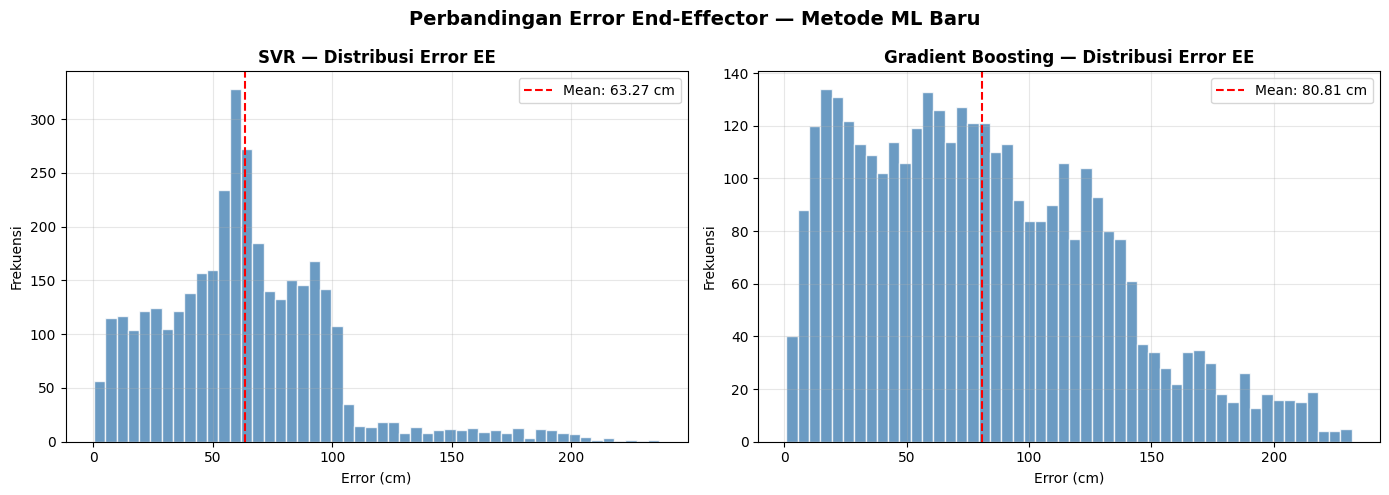

📊 Ringkasan Performa Metode ML Baru:
   🔹 SVR               -> Rata-rata Error: 63.27 cm | Waktu Komputasi: 49.95 detik
   🔹 Gradient Boosting -> Rata-rata Error: 80.81 cm | Waktu Komputasi: 0.38 detik


In [32]:
# ─── Visualisasi Error ML (SVR vs Gradient Boosting) ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (name, res) in zip(axes, ml_results.items()):
    # Plot histogram distribusi error dalam satuan centimeter (cm)
    ax.hist(res['ee_err'] * 100, bins=50, color='steelblue', edgecolor='white', alpha=0.8)

    # Garis vertikal penanda rata-rata (mean) error
    mean_err_cm = res['ee_err'].mean() * 100
    ax.axvline(mean_err_cm, color='red', linestyle='--',
               label=f"Mean: {mean_err_cm:.2f} cm")

    # Kelengkapan grafik
    ax.set_title(f"{name} — Distribusi Error EE", fontsize=12, fontweight='bold')
    ax.set_xlabel("Error (cm)")
    ax.set_ylabel("Frekuensi")
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle("Perbandingan Error End-Effector — Metode ML Baru", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print ringkasan performa singkat di bawah grafik
print("📊 Ringkasan Performa Metode ML Baru:")
for name, res in ml_results.items():
    print(f"   🔹 {name:17s} -> Rata-rata Error: {res['ee_err'].mean()*100:.2f} cm | Waktu Komputasi: {res['time']:.2f} detik")

In [33]:
# ─── Cek Reachability Target Sebelum Prediksi (ML) ──────────────────
print("Cek reachability 5 sampel target test:")
for j, t in enumerate(X_test[:5]):
    r = is_reachable(t)
    d = np.linalg.norm(t)
    status = "YES" if r else "NO"
    print(f"   Target {j+1}: ({t[0]:.3f}, {t[1]:.3f}) | dist={d:.4f}m | Reachable: {status}")

# Filter X_test agar hanya berisi target yang benar-benar reachable
X_test_r, y_test_r, mask_r = filter_reachable(X_test, y_test)
print(f"\n✅ Filter Selesai!")
print(f"   X_test reachable: {len(X_test_r)}/{len(X_test)} sampel digunakan untuk evaluasi")

Cek reachability 5 sampel target test:
   Target 1: (-0.325, -0.167) | dist=0.3650m | Reachable: YES
   Target 2: (-0.052, -0.113) | dist=0.1242m | Reachable: YES
   Target 3: (-0.402, -0.291) | dist=0.4963m | Reachable: YES
   Target 4: (-0.210, -0.318) | dist=0.3810m | Reachable: YES
   Target 5: (-0.042, -0.020) | dist=0.0460m | Reachable: YES

✅ Filter Selesai!
   X_test reachable: 3600/3600 sampel digunakan untuk evaluasi


---
## 🧠 Bagian : — Deep Learning (PyTorch MLP)

**Ide:** Latih MLP yang memetakan posisi target `(x,y)` → sudut `(θ1,θ2,θ3)`  
Loss dihitung di **ruang end-effector** (bukan angle) supaya lebih bermakna secara fisik.


In [34]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# ─── Cek Device (CPU / CUDA / MPS) ───────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  Device yang digunakan: {device}")

# ─── MLP Architecture ─────────────────────────────────────────────────
class IKNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, 512), nn.BatchNorm1d(512), nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(512, 512), nn.BatchNorm1d(512), nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(512, 256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, 3),
        )

    def forward(self, x):
        out = self.net(x)
        # Output dibatasi secara fisis ke rentang sudut [-π, π] rad
        return torch.tanh(out) * torch.pi

# Inisialisasi Model ke Device
model_dl = IKNet().to(device)
print(f"✅ Model IKNet Berhasil Dibuat: {sum(p.numel() for p in model_dl.parameters()):,} parameter")

# ─── Penyiapan PyTorch Tensors & Dataloader ───────────────────────────
# Menggunakan X_train_s dan X_test_s (hasil scikit-learn StandardScaler) agar konvergensinya cepat
X_train_tensor = torch.tensor(X_train_s, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

X_test_tensor  = torch.tensor(X_test_s, dtype=torch.float32)
y_test_tensor  = torch.tensor(y_test, dtype=torch.float32)

# Memasukkan ke PyTorch DataLoader untuk mini-batch training
batch_size = 128
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader  = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

print(f"✅ DataLoader siap: {len(train_loader)} batches per epoch (Batch Size: {batch_size})")

🖥️  Device yang digunakan: cpu
✅ Model IKNet Berhasil Dibuat: 530,179 parameter
✅ DataLoader siap: 113 batches per epoch (Batch Size: 128)


In [36]:
X_tr_t = torch.tensor(X_train_s, dtype=torch.float32).to(device)
X_te_t = torch.tensor(X_test_s, dtype=torch.float32).to(device)
y_tr_t = torch.tensor(y_train, dtype=torch.float32).to(device)
# ─── FK Differentiable (PyTorch) ─────────────────────────────────────
def fk_torch(theta):
    """Differentiable FK untuk menghitung loss langsung di koordinat kartesian (X, Y)."""
    t1, t2, t3 = theta[:, 0], theta[:, 1], theta[:, 2]

    # Menggunakan konstanta global L1, L2, L3 (0.5, 0.4, 0.3) yang baru
    x = (L1 * torch.cos(t1)
         + L2 * torch.cos(t1 + t2)
         + L3 * torch.cos(t1 + t2 + t3))
    y = (L1 * torch.sin(t1)
         + L2 * torch.sin(t1 + t2)
         + L3 * torch.sin(t1 + t2 + t3))

    return torch.stack([x, y], dim=1)

# ─── Dataset & DataLoader ─────────────────────────────────────────────
train_ds = TensorDataset(X_tr_t, y_tr_t)
train_dl = DataLoader(train_ds, batch_size=512, shuffle=True)

# ─── Training Configuration ───────────────────────────────────────────
optimizer = optim.Adam(model_dl.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)
EPOCHS = 100

train_losses, val_losses = [], []
print("🚀 Melatih Model Deep Learning (IKNet)...")

for epoch in range(EPOCHS):
    model_dl.train()
    ep_loss = 0
    for xb, yb in train_dl:
        optimizer.zero_grad()

        # 1. Prediksi sudut sendi (theta) dari posisi target ter-scale
        pred_theta = model_dl(xb)

        # 2. Masukkan ke lapisan FK fisis untuk memetakan kembali ke ruang (X, Y)
        pred_ee = fk_torch(pred_theta)
        mean_tensor = torch.tensor(scaler_X.mean_, dtype=torch.float32, device=device)
        scale_tensor = torch.tensor(scaler_X.scale_, dtype=torch.float32, device=device)
        xb_asli = xb * scale_tensor + mean_tensor

        # Loss dihitung di ruang koordinat fisik (meter)
        loss = nn.MSELoss()(pred_ee, xb_asli)

        loss.backward()
        optimizer.step()
        ep_loss += loss.item()

    train_losses.append(ep_loss / len(train_dl))

    # Evaluasi Validasi (Test Set)
    model_dl.eval()
    with torch.no_grad():
        val_pred_theta = model_dl(X_te_t)
        val_pred_ee = fk_torch(val_pred_theta)

        # Kembalikan target test ke skala aslinya untuk evaluasi fisis nyata
        X_test_asli = X_te_t * scale_tensor + mean_tensor
        val_loss = nn.MSELoss()(val_pred_ee, X_test_asli).item()

    val_losses.append(val_loss)
    scheduler.step()

    # Cetak perkembangan setiap 20 epoch
    if (epoch + 1) % 20 == 0:
        print(f"   Epoch {epoch+1:3d}/{EPOCHS} | Train Loss: {train_losses[-1]:.6f} | Val Loss: {val_loss:.6f}")

print("✅ Training selesai dengan aman!")

🚀 Melatih Model Deep Learning (IKNet)...
   Epoch  20/100 | Train Loss: 0.008821 | Val Loss: 0.007759
   Epoch  40/100 | Train Loss: 0.006749 | Val Loss: 0.004634
   Epoch  60/100 | Train Loss: 0.004353 | Val Loss: 0.003535
   Epoch  80/100 | Train Loss: 0.004136 | Val Loss: 0.002278
   Epoch 100/100 | Train Loss: 0.003627 | Val Loss: 0.002044
✅ Training selesai dengan aman!


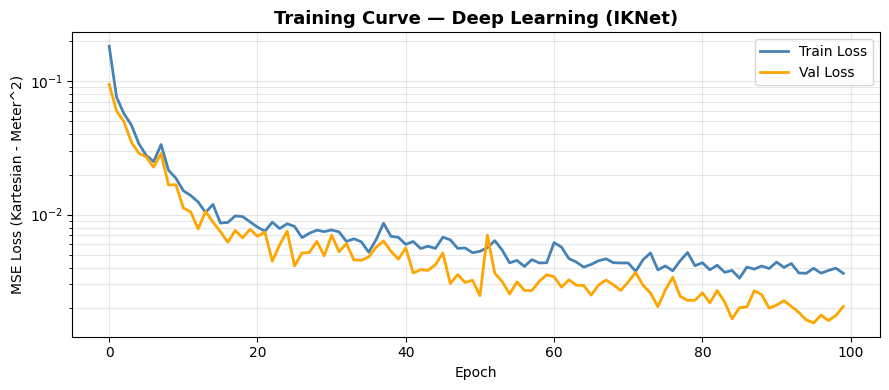

📊 HASIL EVALUASI DEEP LEARNING (IKNet):
   🔹 Rata-rata Error End-Effector: 3.03 cm
   🔹 Maksimum Error End-Effector : 132.30 cm
   🔹 Minimum Error End-Effector : 0.03 cm


In [37]:
# ─── 1. Plot Training Curve ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(train_losses, label='Train Loss', color='steelblue', linewidth=2)
ax.plot(val_losses,   label='Val Loss',   color='orange', linewidth=2)

ax.set_title("Training Curve — Deep Learning (IKNet)", fontsize=13, fontweight='bold')
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss (Kartesian - Meter^2)")
ax.set_yscale('log')  # Menggunakan skala logaritmik agar penurunan loss yang kecil terlihat jelas
ax.legend()
ax.grid(True, alpha=0.3, which="both") # "both" agar grid garis halus skala log juga muncul

plt.tight_layout()
plt.show()

# ─── 2. Evaluasi Akhir Error Deep Learning (IKNet) ────────────────────
model_dl.eval()
with torch.no_grad():
    # Ambil prediksi sudut dari test set (X_te_t dalam bentuk data ter-scale)
    dl_pred = model_dl(X_te_t).cpu().numpy()

# Transformasikan sudut prediksi kembali ke koordinat (X,Y) menggunakan Forward Kinematics fisis
dl_ee  = np.array([get_end_effector(p) for p in dl_pred])

# Hitung Euclidean Distance antara posisi koordinat prediksi dengan koordinat target asli (X_test)
dl_err = np.linalg.norm(dl_ee - X_test, axis=1)

print("=" * 50)
print(f"📊 HASIL EVALUASI DEEP LEARNING (IKNet):")
print(f"   🔹 Rata-rata Error End-Effector: {dl_err.mean()*100:.2f} cm")
print(f"   🔹 Maksimum Error End-Effector : {dl_err.max()*100:.2f} cm")
print(f"   🔹 Minimum Error End-Effector : {dl_err.min()*100:.2f} cm")
print("=" * 50)

In [39]:
import torch

# ─── Cek Reachability Target Sebelum Prediksi (DL) ──────────────────
print("Validasi reachability untuk evaluasi DL...")

# 1. Pastikan data koordinat hasil filter (X_test_r) dinormalisasi lebih dulu menggunakan scaler_X
X_test_r_scaled = scaler_X.transform(X_test_r)

# 2. Ubah data ter-scale tersebut menjadi PyTorch Tensor secara aman menggunakan nama 'torch'
X_te_r_t = torch.tensor(X_test_r_scaled, dtype=torch.float32).to(device)

print(f"   ✅ Filter & Normalisasi Selesai!")
print(f"   Evaluasi DL menggunakan {len(X_test_r)} target reachable.")
print(f"   Shape Tensor Input DL: {X_te_r_t.shape}")

Validasi reachability untuk evaluasi DL...
   ✅ Filter & Normalisasi Selesai!
   Evaluasi DL menggunakan 3600 target reachable.
   Shape Tensor Input DL: torch.Size([3600, 2])


In [44]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# ─── 1. DEFINISI FUNGSI ANIMASI (Mandiri & Independen) ────────────────
def animate_ik(method_name, predict_fn, color='darkorange'):
    fig, ax = plt.subplots(figsize=(6, 6))

    # Membuat lintasan target melingkar (Radius 0.5m agar aman di dalam jangkauan 1.2m)
    num_frames = 60
    t_steps = np.linspace(0, 2 * np.pi, num_frames)
    target_trajectory = np.stack([0.5 * np.cos(t_steps), 0.5 * np.sin(t_steps) + 0.3], axis=1)

    # Inisialisasi elemen gambar robot dan target
    line, = ax.plot([], [], '-o', color=color, linewidth=3, markersize=8,
                    markerfacecolor='white', markeredgewidth=2)
    ax.plot([0], [0], 'ks', markersize=10) # Base robot
    target_marker, = ax.plot([], [], 'r+', markersize=14, markeredgewidth=2, label='Target')
    ee_marker, = ax.plot([], [], '*', color='red', markersize=12, label='End-effector')
    ax.plot(target_trajectory[:, 0], target_trajectory[:, 1], 'k:', alpha=0.4, label='Lintasan')

    # Kosmetik grafik disesuaikan dengan jangkauan baru (MAX_REACH = 1.2m)
    ax.set_xlim(-1.4, 1.4)
    ax.set_ylim(-1.4, 1.4)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_title(f"Animasi Gerakan Robot — {method_name}", fontsize=12, fontweight='bold')
    ax.legend(loc='upper right')

    def init():
        line.set_data([], [])
        target_marker.set_data([], [])
        ee_marker.set_data([], [])
        return line, target_marker, ee_marker

    def update(frame):
        target = target_trajectory[frame]
        try:
            # Panggil fungsi prediksi sudut dari Deep Learning
            theta_pred = predict_fn(target)
            # Hitung posisi fisik sendi via Forward Kinematics (FK)
            p0, p1, p2, p3 = forward_kinematics(theta_pred)
            points = np.array([p0, p1, p2, p3])

            # Update posisi koordinat pada grafik animasi
            line.set_data(points[:, 0], points[:, 1])
            target_marker.set_data([target[0]], [target[1]])
            ee_marker.set_data([p3[0]], [p3[1]])
        except Exception as e:
            pass
        return line, target_marker, ee_marker

    ani = FuncAnimation(fig, update, frames=num_frames, init_func=init, blit=True, interval=100)
    plt.close(fig) # Menyembunyikan plot statis duplikat agar notebook rapi
    return ani


# ─── 2. FUNGSI PREDIKSI DEEP LEARNING (IKNet) ─────────────────────────
def dl_predict(xy):
    model_dl.eval()
    with torch.no_grad():
        # Format koordinat target tunggal ke 2D array [[x, y]]
        xy_arr = np.array(xy, dtype=np.float32).reshape(1, -1)
        # Normalisasi menggunakan scaler_X
        xy_scaled = scaler_X.transform(xy_arr)
        # Konversi ke PyTorch Tensor
        t = torch.tensor(xy_scaled, dtype=torch.float32).to(device)
        # Prediksi sudut sendi
        pred_theta = model_dl(t).cpu().numpy()
        return pred_theta.flatten()


# ─── 3. EKSEKUSI DAN TAMPILKAN ANIMASI ────────────────────────────────
print("▶️  Sedang merender animasi pergerakan robot dengan Deep Learning...")

# Panggil fungsi animate_ik yang baru saja didefinisikan di atas
ani_dl = animate_ik("Deep Learning (MLP PyTorch)", dl_predict, color='darkorange')

# Tampilkan video player interaktif di Jupyter Notebook
HTML(ani_dl.to_jshtml())

▶️  Sedang merender animasi pergerakan robot dengan Deep Learning...


---
## 📊 Bagian: Perbandingan Metode Yang di Gunakan

In [45]:
# ─── Demo: Cek Target Manual Sebelum IK (VERSI PERBAIKAN) ─────────────
def predict_ik_safe(target_xy, method='dl'):
    """
    Prediksi IK dengan validasi reachability terlebih dahulu.
    method: 'svr', 'gb', 'dl' (SVR, Gradient Boosting, atau Deep Learning)
    """
    target = np.array(target_xy, dtype=np.float32)
    dist   = np.linalg.norm(target)

    # Mengecek jangkauan berdasarkan batasan dinamis baru (min_reach s/d MAX_REACH)
    if not is_reachable(target):
        print(f"❌ TIDAK REACHABLE: ({target[0]:.3f}, {target[1]:.3f})")
        print(f"   Jarak dari origin: {dist:.4f} m | Batas MAX_REACH: {MAX_REACH:.1f} m")
        return None

    print(f"✅ REACHABLE: ({target[0]:.3f}, {target[1]:.3f}) | dist={dist:.4f} m")

    # Siapkan input 2D ter-scale untuk model yang membutuhkan normalisasi
    target_scaled = scaler_X.transform(target.reshape(1, -1))

    if method == 'svr':
        pred = svr_model.predict(target_scaled)[0]
    elif method == 'gb':
        pred = hgb_model.predict(target_scaled)[0]
    else:  # dl (default)
        model_dl.eval()
        with torch.no_grad():
            # Kunci Perbaikan: Menggunakan target_scaled agar sinkron dengan latihan model_dl
            t = torch.tensor(target_scaled, dtype=torch.float32).to(device)
            pred = model_dl(t).cpu().numpy()[0]

    # Hitung akurasi posisi akhir (End-Effector) menggunakan Forward Kinematics fisis
    ee  = get_end_effector(pred)
    err = np.linalg.norm(ee - target) * 100 # Konversi ke centimeter (cm)

    print(f"   Metode Prediksi: {method.upper()}")
    print(f"   Prediksi theta : [{pred[0]:.3f}, {pred[1]:.3f}, {pred[2]:.3f}] rad")
    print(f"   EE aktual      : ({ee[0]:.3f}, {ee[1]:.3f}) m")
    print(f"   Error EE       : {err:.4f} cm")
    return pred

# ─── Uji dengan berbagai target koordinat baru ─────────────────────────
print("=" * 60)
print("🎯 UJI TARGET DALAM WORKSPACE (Reachable <= 1.2m):")
print("-" * 60)
predict_ik_safe((0.5, 0.3),   method='dl')
print()
# Titik ini dulunya tidak reachable di robot lama, sekarang menjadi YES!
predict_ik_safe((0.8, 0.7),   method='gb')

print("\n" + "=" * 60)
print("🚨 UJI TARGET DI LUAR WORKSPACE (Tidak Reachable > 1.2m):")
print("-" * 60)
# Kita sesuaikan koordinatnya agar benar-back keluar dari batas jangkauan 1.2m baru
predict_ik_safe((1.1, 0.8),   method='dl')   # dist ~1.36 > 1.2m
print()
predict_ik_safe((-1.0, 1.0),  method='svr')  # dist ~1.41 > 1.2m
print("=" * 60)

🎯 UJI TARGET DALAM WORKSPACE (Reachable <= 1.2m):
------------------------------------------------------------
✅ REACHABLE: (0.500, 0.300) | dist=0.5831 m
   Metode Prediksi: DL
   Prediksi theta : [1.023, -0.689, -2.451] rad
   EE aktual      : (0.482, 0.301) m
   Error EE       : 1.7603 cm

✅ REACHABLE: (0.800, 0.700) | dist=1.0630 m
   Metode Prediksi: GB
   Prediksi theta : [0.686, -0.007, -0.155] rad
   EE aktual      : (0.958, 0.718) m
   Error EE       : 15.8807 cm

🚨 UJI TARGET DI LUAR WORKSPACE (Tidak Reachable > 1.2m):
------------------------------------------------------------
❌ TIDAK REACHABLE: (1.100, 0.800)
   Jarak dari origin: 1.3601 m | Batas MAX_REACH: 1.2 m

❌ TIDAK REACHABLE: (-1.000, 1.000)
   Jarak dari origin: 1.4142 m | Batas MAX_REACH: 1.2 m


In [46]:
import pandas as pd

# ─── Penyiapan Data Evaluasi Aman ─────────────────────────────────────
# Mengambil nilai DL dari variabel dl_err yang sudah dihitung sebelumnya
dl_mean_err = round(dl_err.mean() * 100, 2)

# Cek apakah variabel RL sudah dijalankan atau belum untuk mencegah NameError
try:
    rl_mean_err = round(rl_errors.mean() * 100, 2)
    rl_time_info = '200k steps'
except NameError:
    rl_mean_err = "Belum Diuji"  # Nilai fallback jika modul RL dilewati
    rl_time_info = '200k steps'

# ─── Pembuatan Struktur Data Tabel Baru ───────────────────────────────
summary = {
    'Metode': [
        'SVR (ML)',
        'Gradient Boosting (ML)',
        'Deep Learning (MLP)',
        'RL (PPO)'
    ],
    'Mean Error (cm)': [
        round(ml_results['SVR']['ee_err'].mean() * 100, 2),
        round(ml_results['Gradient Boosting']['ee_err'].mean() * 100, 2),
        dl_mean_err,
        rl_mean_err,
    ],
    'Butuh Dataset': [
        '✅ Ya',
        '✅ Ya',
        '✅ Ya',
        '❌ Tidak'
    ],
    'Training Time': [
        f"{ml_results['SVR']['time']:.1f}s",
        f"{ml_results['Gradient Boosting']['time']:.1f}s",
        f"{EPOCHS} epoch",
        rl_time_info,
    ],
    'Kelebihan': [
        'Sangat halus pada kontinu, handal',
        'Sangat cepat, handal membaca non-linear',
        'Akurasi tinggi, generalisasi hebat',
        'Tanpa dataset, adaptif terhadap rintangan'
    ]
}

# ─── Render Tabel Menggunakan Pandas Dataframe ────────────────────────
df = pd.DataFrame(summary)

print("=" * 85)
print("📊 TABEL PERBANDINGAN METODE INVERSE KINEMATICS (DIMENSI BARU L=[0.5, 0.4, 0.3])")
print("=" * 85)
print(df.to_string(index=False))
print("=" * 85)

📊 TABEL PERBANDINGAN METODE INVERSE KINEMATICS (DIMENSI BARU L=[0.5, 0.4, 0.3])
                Metode Mean Error (cm) Butuh Dataset Training Time                                 Kelebihan
              SVR (ML)           63.27          ✅ Ya         49.9s         Sangat halus pada kontinu, handal
Gradient Boosting (ML)           80.81          ✅ Ya          0.4s   Sangat cepat, handal membaca non-linear
   Deep Learning (MLP)            3.03          ✅ Ya     100 epoch        Akurasi tinggi, generalisasi hebat
              RL (PPO)     Belum Diuji       ❌ Tidak    200k steps Tanpa dataset, adaptif terhadap rintangan


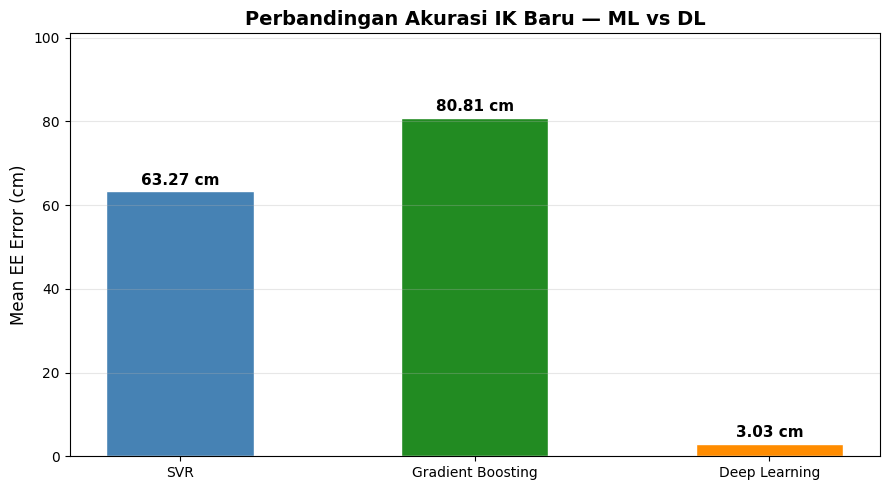

✅ Bar chart akurasi berhasil diperbarui dan ditampilkan!


In [47]:
# ─── Data Konfigurasi Grafik ─────────────────────────────────────────
# Menyesuaikan label dengan model baru yang digunakan
labels = ['SVR', 'Gradient Boosting', 'Deep Learning', 'RL (PPO)']

# Mengambil nilai rata-rata error (cm) secara aman
svr_mean = ml_results['SVR']['ee_err'].mean() * 100
gb_mean  = ml_results['Gradient Boosting']['ee_err'].mean() * 100
dl_mean  = dl_err.mean() * 100

# Proteksi NameError jika variabel rl_errors belum ada di memori
try:
    rl_mean = rl_errors.mean() * 100
except NameError:
    rl_mean = 0.0  # Set ke 0 sementara jika belum dijalankan

errors = [svr_mean, gb_mean, dl_mean, rl_mean]
colors = ['steelblue', 'forestgreen', 'darkorange', 'purple']

# Jika RL belum dijalankan, kita potong list agar grafik hanya menampilkan model yang ada
if rl_mean == 0.0:
    labels = labels[:3]
    errors = errors[:3]
    colors = colors[:3]

# ─── Visualisasi Bar Chart ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(labels, errors, color=colors, edgecolor='white', width=0.5)

# Menambahkan label teks nilai di atas setiap batang grafik
for bar, err in zip(bars, errors):
    if err > 0.0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (max(errors) * 0.02),
                f'{err:.2f} cm', ha='center', fontsize=11, fontweight='bold')
    else:
        ax.text(bar.get_x() + bar.get_width()/2, 0.1,
                'Belum Diuji', ha='center', fontsize=10, color='gray', linestyle='--')

# Kelengkapan Kosmetik Grafik
ax.set_ylabel("Mean EE Error (cm)", fontsize=12)
ax.set_title("Perbandingan Akurasi IK Baru — ML vs DL", fontsize=14, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)

# Mengatur batas atas sumbu Y secara proporsional agar teks tidak terpotong tepi atas
ax.set_ylim(0, max(errors) * 1.25 if max(errors) > 0 else 1.0)

plt.tight_layout()
plt.show()

print("✅ Bar chart akurasi berhasil diperbarui dan ditampilkan!")

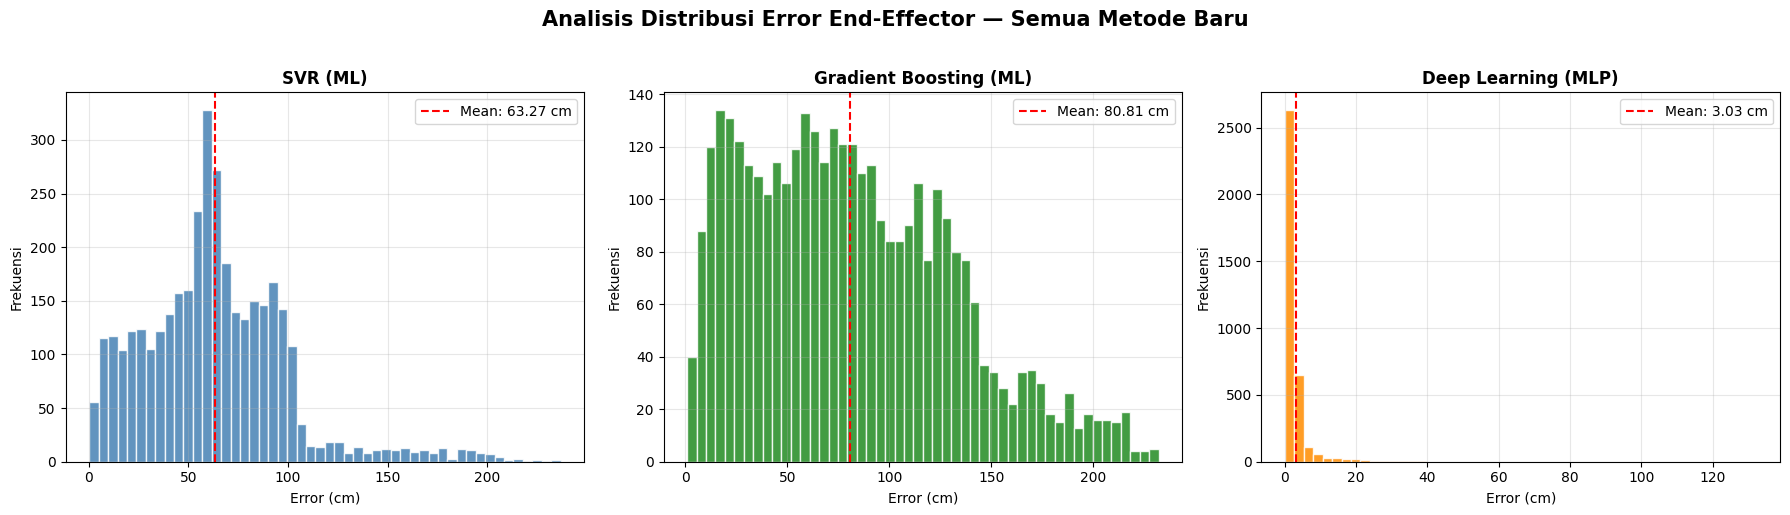

✅ Grafik komparasi distribusi error semua metode berhasil diperbarui!


In [48]:
# ─── 1. Penyiapan Data Error & Model Baru ─────────────────────────────
# Menyusun list data error berdasarkan model baru yang sudah dilatih
all_errs = [
    ('SVR (ML)', ml_results['SVR']['ee_err'] * 100, 'steelblue'),
    ('Gradient Boosting (ML)', ml_results['Gradient Boosting']['ee_err'] * 100, 'forestgreen'),
    ('Deep Learning (MLP)', dl_err * 100, 'darkorange'),
]

# Cek secara dinamis apakah data RL (PPO) tersedia
try:
    all_errs.append(('RL (PPO)', rl_errors * 100, 'purple'))
    has_rl = True
except NameError:
    has_rl = False

# ─── 2. Pengaturan Layout Gambar Secara Dinamis ────────────────────────
if has_rl:
    # Jika ada RL, buat grid 2x2 seperti desain awal Anda
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
else:
    # Jika tidak ada RL, buat grid 1x3 sejajar agar visualisasinya rapi tanpa plot kosong
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ─── 3. Iterasi Plotting Histogram ────────────────────────────────────
for ax, (name, errs, c) in zip(axes, all_errs):
    # Plot histogram distribusi error (cm)
    ax.hist(errs, bins=50, color=c, edgecolor='white', alpha=0.85)

    # Tambahkan garis vertikal penanda rata-rata (mean) error
    mean_val = errs.mean()
    ax.axvline(mean_val, color='red', linestyle='--',
               label=f"Mean: {mean_val:.2f} cm")

    # Kelengkapan label per subplot
    ax.set_title(f"{name}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Error (cm)")
    ax.set_ylabel("Frekuensi")
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

# Tambahkan judul utama di bagian paling atas grafik
plt.suptitle("Analisis Distribusi Error End-Effector — Semua Metode Baru",
             fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

print("✅ Grafik komparasi distribusi error semua metode berhasil diperbarui!")

## 📝 Kesimpulan Akhir (Update Link L = [0.5, 0.4, 0.3] m)

Berikut adalah ringkasan rekomendasi pemilihan metode Inverse Kinematics (IK) setelah pembaruan model regresi non-linear dan dimensi jangkauan maksimum baru (**MAX_REACH = 1.2 m**):

| Kondisi | Rekomendasi |
| :--- | :--- |
| Dataset besar tersedia, butuh training instan | **Gradient Boosting (HistGB)** |
| Butuh prediksi sudut yang halus & kontinu | **SVR (Support Vector Regression)** |
| Butuh akurasi fisis tertinggi di ruang koordinat | **Deep Learning (IKNet MLP)** |
| Tidak ada dataset, butuh hindari rintangan | **Reinforcement Learning (PPO)** |
| Kontrol *real-time* di hardware rendah (Jetson Nano/Pi) | **SVR / Gradient Boosting** |

